# Introduction to Optimization

In this course, we'll be interested in designing engineering systems through formal design optimization methods.
A key assumption that we will make is that the performance of an engineering system that we wish to design can be captured by a mathematical function that returns a scalar value:
\begin{equation*}
f(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}.
\end{equation*}
Here $f$ is a scalar function of interest and $x \in \mathbb{R}^{n}$ are a vector of $n$ design variables.

Later in the course, we will add inequality constraints to the design problem, generally denoted
\begin{equation*}
c(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}^{m}.
\end{equation*}
Here $c$ is a vector of constraint functions $c(x) \in \mathbb{R}^{m}$.
The inequality constraints $c(x) \le 0$, where the inequality is component-wise, such that $c_{i}(x) \le 0$ for $i = 1,\ldots,m$.
A design point $x$ that where the inequality constraints are satisfied is called *feasible*, while a point at which the inequality constraints are violated is called *infeasible*.

## Design formulation and parametrization

The combination of the objective and constraints constitutes the design formulation.
The goal of the optimization methods we will study in this course is to find a solution to an optimization problem that takes the form

\begin{equation*}
\begin{aligned}
\min \qquad & f(x) \\
\text{with respect to} \qquad & x \\
\text{such that} \qquad & c(x) \le 0
\end{aligned}
\end{equation*}

Note that we focus on *minimization* in all our optimization algorithms.
If instead we want to *maximize* a function of interest, we can minimize $- f(x)$.
This optimization problem consists of both an objective and a set of constraints and is therefore called a *constrained optimization* problem. Solving constrained optimization problem requires specialized optimization theory and algorithms to solve efficiently that we will cover later in the course.
As we will see, constraints are challenging to handle and add significantly to the complexity of optimization theory and algorithms.

As a first step, we will examine the simpler problem of minimizing a function of interest without any constraints.
This type of optimization problem is called an *unconstrained optimization* problem. 
The unconstrained problem formulation takes the form

\begin{equation*}
\begin{aligned}
\min \qquad & f(x) \\
\text{with respect to} \qquad & x \\
\end{aligned}
\end{equation*}

If you want to use formal optimization methods to design an engineering system, it is important to first think about problem formulation itself.
What constitutes the right objective to reflect your engineering intent?
What are an appropriate set of constraints?
What are the design variables that should be used to parameterize the design space?
Furthermore, there are mathematically equivalent ways to pose the same constraint, and sometimes certain formulations work better than others.
We'll explore this more concretely later in the course.

## Simulation-based optimization

In much of the course, we'll work with simple models where we can explicitly write out the dependence of $f(x)$ on the design variables $x$.
However, in many engineering applications, $f(x)$ is actually the result of a simulation.
Some examples:

- $f(x)$ may be the drag on an airfoil computed using computational fluid dynamics (CFD)
- $f(x)$ may be an approximate maximum stress in a wing computed using the finite-element method

In these cases, it is not possible to write $f(x) = x_{1}^2 + 3x_{2}^{2}$ or any such explicit expressions.

## Types of optimization algorithms and their performance

In this course we'll examine different types of optimization algorithms.
All optimization algorithms use information from the objective and constraints to find an optimized point.
Optimization algorithms that require both function values and the derivative or gradient of the objective and constraint functions are called *gradient-based methods*, or *first-order methods*.
Sometimes gradient-based methods may also use the Hessian, or matrix of second-order derivatives.
However, the second derivatives may be computationally expensive to evaluate in simulation-based optimization cases.
Optimization algorithms that require only function values are called *gradient-free methods* or *zeroth order methods*.

What optimizer performance metrics should we be interested in when comparing optimization algorithms?
When evaluating the performance of an optimizer, we'll generally be interested in:

1. Number of objective and constraint function evaluations
2. Number of evaluations of the objective and constraint gradients (if using a gradient-based optimizer)
3. Computational time to complete the optimization
4. Accuracy of the optimized point

In simulation-based optimization, the cost of the simulation can be orders of magnitude greater than any computational costs associated with the optimization algorithm itself.
As a result, the number of function and gradient evaluations dominates the total computational time.
However, when the objective and constraints are computationally inexpensive to evaluate, the computational time spent in the optimization algorithm can be significant.

The accuracy of the optimized point is difficult to assess.
If you know the answer ahead of time, then you could look at the distance between the optimized point and the true exact optimum.
However, in most cases we won't know the answer ahead of time, so we can't compute the error in the solution to assess accuracy.
Instead, we can try and understand accuracy by looking at example problems where we do know the solution.

### Example

Here we look at the multi-dimensional [Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function)

\begin{equation*}
f(x) = \sum_{i=1}^{n/2} \left( 100(x_{2i-1}^2 - x_{2i})^2 + (x_{2i-1} - 1)^2 \right)
\end{equation*}

This variant of the multi-dimensional Rosenbrock function is known as a separable function.

Here we'll look at the behavior of four optimizers on the unconstrained minimization problem of the Rosenbrock function:

1. [Nelder-Mead](https://en.wikipedia.org/wiki/Nelder%E2%80%93Mead_method): A gradient-free optimizer
2. [Powell's method](https://en.wikipedia.org/wiki/Powell%27s_method): A gradient-free optimizer
3. [BFGS](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm): A gradient based optimization algorithm with the exact gradient
4. BFGS with a gradient vector computed using finite-differences

This example uses [scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html).

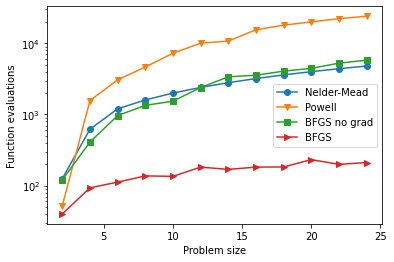

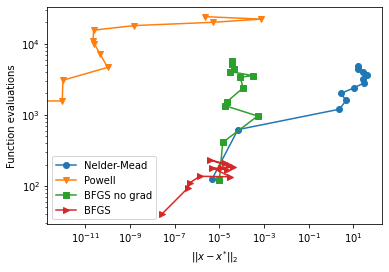

In [1]:
# Example minimization demonstrating the cost-accuracy
# tradeoff between gradient-based and gradient-free methods
import numpy as np
from scipy.optimize import minimize
import matplotlib.pylab as plt

class Rosenbrock:
    def __init__(self, N):
        """
        Rosenbrock function class
        
        Args:
            N: The dimension of the design space divided by 2
        """
        self.N = N

    def function(self, x):
        """
        Multi-dimensional Rosenbrock function
        """

        fval = 0.0
        for i in range(self.N):
            fval += 100.0*(x[2*i]**2 - x[2*i+1])**2 + (x[2*i] - 1.0)**2

        return fval

    def gradient(self, x):
        """
        Compute the gradient of the multi-dimensional Rosenbrock function
        """

        grad = np.zeros(len(x))

        for i in range(self.N):
            grad[2*i] = 200.0*(x[2*i]**2 - x[2*i+1])*(2.0*x[2*i]) + 2.0*(x[2*i] - 1.0)
            grad[2*i+1] = -200.0*(x[2*i]**2 - x[2*i+1])

        return grad

# The dimension of the design space
sizes = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

# Store the optimized results in lists
res_nelder_mead = []
res_powell = [] 
res_bfgs_no_grad = []
res_bfgs = []

for n in sizes:
    # Set the starting point at x0 = -1.0
    x0 = -np.ones(n)

    # Create the Rosenbrock function class
    rosen = Rosenbrock(n//2)
        
    res_nelder_mead.append(minimize(rosen.function, x0, method='Nelder-Mead'))
    res_powell.append(minimize(rosen.function, x0, method='Powell'))
    res_bfgs_no_grad.append(minimize(rosen.function, x0, method='bfgs'))
    res_bfgs.append(minimize(rosen.function, x0, jac=rosen.gradient, method='bfgs'))
    
# Compare the accuracy vs. computational cost
def process_results(res_list):
    nfevals = []
    accuracy = []
    for res in res_list:
        nfevals.append(res.nfev) # Number of function evaluations
        
        # Compute the error in the solution vector: Norm of the
        # difference between the exact solution and the optimized solution
        err = res.x - np.ones(len(res.x))
        accuracy.append(np.sqrt(np.dot(err, err)))
    return nfevals, accuracy

# Process the results to get the number of function evaluations and the solution accuracy
nfe_nm, acc_nm = process_results(res_nelder_mead)
nfe_p, acc_p = process_results(res_powell)
nfe_bfgs_ng, acc_bfgs_ng = process_results(res_bfgs_no_grad)
nfe_bfgs, acc_bfgs = process_results(res_bfgs)

# Plot the number of function evaluations vs. problem size
plt.figure()
plt.semilogy(sizes, nfe_nm, marker='o', label='Nelder-Mead')
plt.semilogy(sizes, nfe_p, marker='v', label='Powell')
plt.semilogy(sizes, nfe_bfgs_ng, marker='s', label='BFGS no grad')
plt.semilogy(sizes, nfe_bfgs, marker='>', label='BFGS')
plt.ylabel('Function evaluations')
plt.xlabel('Problem size')
plt.legend()

# Plot the optimized solution accuracy vs. function evaluations
plt.figure()
plt.loglog(acc_nm, nfe_nm, marker='o', label='Nelder-Mead')
plt.loglog(acc_p, nfe_p, marker='v', label='Powell')
plt.loglog(acc_bfgs_ng, nfe_bfgs_ng, marker='s', label='BFGS no grad')
plt.loglog(acc_bfgs, nfe_bfgs, marker='>', label='BFGS')
plt.ylabel('Function evaluations')
plt.xlabel(r'$||x - x^{*}||_{2}$')
plt.legend()
plt.show()

## One-dimensional minimization from calculus

In calculus, there is a simple approach to finding the minimizers of a function of a single variable $f(x) : \mathbb{R} \rightarrow \mathbb{R}$.

1. Find any critical points $x_{cr}$ by solving the equation $f'(x) = 0$, such that $f'(x_{cr}) = 0$.
2. Evaluate the second derivative of the function at the critical points. If $f''(x_{cr}) > 0$, then the point is a local or global minimizer, if $f''(x_{cr}) < 0$ the point is a local or global maximizer. If $f''(x_{cr}) = 0$, higher derivatives are needed to definitively characterize the point

We will find that similar, but more complex criteria are required for multi-dimensional problems.

### Examples

Find the critical points and characterize them for the following functions

1. $f(x) = x^{2} - x - 1$

$f'(x) = 2x - 1 = 0$ and $f''(x) = 2$. The critical point is $x_{cr} = \dfrac{1}{2}$, which is a minimizer.

2. $f(x) = -x^3 + x^2 + \frac{1}{2} x - 1$.

$f'(x) = -3x^2 + 2x + \dfrac{1}{2} = 0$ and $f''(x) = - 6x + 2$. The critical points are $x_{cr} = \dfrac{2 \pm \sqrt{10}}{6}$. The point $\dfrac{2 - \sqrt{10}}{6}$ is a minimizer. The point $\dfrac{2 + \sqrt{10}}{6}$ is a maximizer.

3. $f(x) = -\cos(5x) + \dfrac{x^2}{100}$

$f'(x) = 5\sin(5x) + \dfrac{x}{50}$.


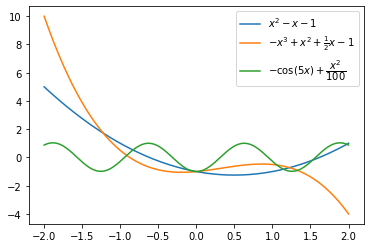

In [3]:
import matplotlib.pylab as plt
import numpy as np

npts = 250
x = np.linspace(-2.0, 2.0, npts)
plt.plot(x, x**2 - x - 1.0, label=r'$x^2 - x - 1$')
plt.plot(x, -x**3 + x**2 + 0.5*x - 1.0, label=r'$-x^3 + x^2 + \frac{1}{2} x - 1$')
plt.plot(x, -np.cos(5*x) + 0.01*x**2, label=r'$-\cos(5x) + \dfrac{x^2}{100}$')
plt.legend()
plt.show()

## Linear Algebra Background

In this course, we will need to use material from linear algebra and calculus. This section serves as a review of the essential topics from those subjects that will be needed for this course.

We will denote a vector $x \in \mathbb{R}^{n}$, and usually we will denote its components by $x_{i}$. (Sometimes we'll also write a series of vectors as $y_{i} \in \mathbb{R}^{n}$ for $i = 1, \ldots, m$ where here the subscript simply denotes vector $i$ in the set.) The components of this column vector $x \in \mathbb{R}^{n}$ can be written as follows
\begin{equation*}
x = \begin{bmatrix}
x_{1} \\ x_{2} \\ x_{3} \\ \vdots \\ x_{n} \\
\end{bmatrix}.
\end{equation*}
We'll often need to write inequalities. Generally $x \ge 0$ will denote that $x_{i} \ge 0$ for $i = 1, \ldots, n$.


### Dot products and norms
Dot products with two vectors $x, y \in \mathbb{R}^{n}$ can be written as follows:

\begin{equation*}
x^{T} y = \sum_{i=1}^{n} x_{i} y_{i}.
\end{equation*}

The norm of a vector is a measure of its length. We'll see a couple different norms. The $\ell_{2}$ norm is related to the dot product such that

\begin{equation*}
||x||_{2} = \left(\sum_{i=1}^{n} x_{i}^{2} \right)^{\frac{1}{2}} = \sqrt{ x^{T} x}.
\end{equation*}

The $\ell_{1}$ norm is a sum of the absolute values of all the components of the vector
\begin{equation*}
||x||_{1} = \sum_{i=1}^{n} |x_{i}|.
\end{equation*}

The $\ell_{\infty}$ norm is the maximum absolute value of a vector
\begin{equation*}
||x||_{\infty} = \max_{i} | x_{i} |.
\end{equation*}

### Matrices

We will also work a lot with both square and rectangular real matrices which we will write as $A \in \mathbb{R}^{m \times n}$, which denotes a matrix with $m$ rows and $n$ columns. The components of this matrix can be written as

\begin{equation*}
A = \begin{bmatrix}
A_{11} & A_{12} & \ldots & A_{1n} \\
A_{21} & A_{22} & \ldots & A_{2n} \\
\vdots & \vdots &        & \\
A_{m1} & A_{m2} & \ldots & A_{mn} \\
\end{bmatrix}
\end{equation*}

### Eigenvalues and Eigenvectors

In this course it is *very* important to understand eigenvalues and eigenvectors. In this course, we will work entirely with eigenvalues of real, square matrices. In other words $A \in \mathbb{R}^{n \times n}$, with $A = A^{T}$. This space of matrices is sometimes written as $A \in \mathbb{S}^{n}$.

The eigenvalue problem can be written as
\begin{equation*}
A q = \lambda q,
\end{equation*}
where $\lambda \in \mathbb{R}$ is a real scalar and $q \in \mathbb{R}^{n}$ is a vector. There are $n$ eigenvalues and eigenvector pairs. The eigenvectors are linearly independent and span $\mathbb{R}^{n}$. Note that if you scale the eigenvector by a constant, $\alpha \in \mathbb{R}$, then $\alpha q$ is also an eigenvector. As a result, it is common to normalize the eigenvectors such that $||q||_{2} = 1$. Other normalizations are possible, such as $||q||_{\infty} = 1$, so be careful if you're computing the eigenvalues using a library.

The eigenvalues can be arranged into a diagonal matrix $\Lambda \in \mathbb{R}^{n \times n}$ where
\begin{equation*}
\Lambda = \text{diag}\{\lambda_{1}, \lambda_{2}, \ldots, \lambda_{n}\},
\end{equation*}
where $\lambda_{i}$ denote the eigenvalues of the matrix $A$. The eigenvectors, $q_{i} \in \mathbb{R}^{n}$, can be arranged column-wise in a matrix $Q \in \mathbb{R}^{n \times n}$
\begin{equation*}
Q = \begin{bmatrix} q_{1} & q_{2} & \ldots & q_{n} \end{bmatrix}.
\end{equation*}

With these definitions, all the eigenvalues satisfy the identity
\begin{equation*}
A Q = Q \Lambda.
\end{equation*}

If the eigenvectors are normalized with respect to the $\ell_{2}$ norm, then $q_{i}^{T} q_{i} = 1$. In addition, the eigenvectors are *orthogonal* such that $q_{i}^{T} q_{j} = 0$ when $i \ne j$. Using these relationships you can find that
\begin{equation*}
Q^{T} Q = I,
\end{equation*}
where $I$ is the identity matrix. *Verify this identity for yourself.*

There are several important facts about eigenvalues of real symmetric matrices that it is important to know. These can be found in any textbook on linear algebra.

1. The eigenvalues of $A = A^{T}$ are real (not complex)
2. A is diagonalizable such that $A = Q \Lambda Q^{T}$ or $\Lambda = Q^{T} A Q$. The first form of this equation can also be written as
\begin{equation*}
A = \sum_{i=1}^{n} \lambda_{i} q_{i} q_{i}^{T}
\end{equation*}
3. If any eigenvalue of a matrix is zero ($\lambda_{i} = 0$ for some $i$), then the matrix is singular

## Definitions

A real symmetric matrix is often classified according to its eigenvalues.

1. If the eigenvalues of $A$ are all strictly positive $\lambda_{i} > 0$, then the matrix $A$ is called *positive definite*. This is also equivalent to demonstrating that $x^{T} A x \ge \alpha x^{T} x$ for some $\alpha > 0$.
2. If the eigenvalues of $A$ are non-negative such that $\lambda_{i} \ge 0$, then the matrix $A$ is called *positive semi-definite*. Note that since we possibly have $\lambda_{i} = 0$, $A$ may be singular when $A$ is only positive semi-definite. 
3. If the eigenvalues of $A$ are both positive and negative, then $A$ is called *indefinite*.
4. If $\lambda_{i} < 0$ then $A$ is *negative definite*.
5. If $\lambda_{i} \le 0$ then $A$ is *negative semi-definite*.


### Examples

It's important to get used to computing the eigenvalues and eigenvectors of small matrices and to understand how they're computed numerically. To get a handle on this we'll consider a few simple cases.

In all computational examples, we'll use the eigh function from python package numpy.linalg. The documentation for this package can be found here: 

https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html

1. First consider the simple diagonal matrix
\begin{equation*}
A = \begin{bmatrix}
1 & 0 \\
0 & 2 \\
\end{bmatrix}
\end{equation*}
You can immediately see that it is already diagonal, so that $A = \Lambda$ in this case with $Q = I$. In other words, the eigenvalues are $\lambda_{1} = 1$ and $\lambda_{2} = 2$, and the eigenvectors are $q_{1} = (1, 0)$ and $q_{2} = (0,1 )$. Don't waste time trying to compute the eigenvalues and eigenvectors of a diagonal matrix. This matrix is positive definite.

2. A more complicated case is the matrix
\begin{equation*}
A = \begin{bmatrix}
2 & 1 \\
1 & 2 \\
\end{bmatrix}
\end{equation*}
Note that in this case, when multiplying $A$ by the vector $v = (1, 1)$ gives $Av = (3, 3) = 3 v$. In other words $\lambda_{1} = 3$ and $q_{1} = (1, 1)/\sqrt{2}$. The second eigenvector must be orthogonal to $v$ so it has to be along the direction $v = (1, -1)$ (so that $v^{T}q_{1} = 0$. Note that $Av = (1, -1) = v$ so the second eigenvalue is $\lambda_{2} = 1$, and $q_{2} = (1, -1)/\sqrt{2}$. This matrix is positive definite.

3. Another more complex case is
\begin{equation*}
A = \begin{bmatrix}
1 & -1 \\
-1 & 1 \\
\end{bmatrix}
\end{equation*}
Note that in this case $v = (1, 1)$ satisfies $Av = 0$, so $\lambda_{1} = 0$, $q_{1} = (1, 1)/\sqrt{2}$ is the first eigen pair. This eigenvector is in the *null space* of the matrix $A$, such that $Av = 0$. The other eigenvector must be orthogonal to this vector so that $v = (1, -1)$. Note that $A v = (2, -2) = 2 v$ so that $\lambda_{2} = 2$ and $q_{2} = (1, -1)/\sqrt{2}$. This matrix is positive semi-definite and singular (its inverse does not exist).

4. Randomly generated matrix. This example computes the eigenvalues of a randomly generated matrix $A = A^{T} \in \mathbb{R}^{10 \times 10}$. Note the eigenvalues are returned by numpy in sorted in increasing order.

5. Construct a matrix with known eigenvalues. In this example, we construct a matrix with known eigenvalues (eigenspectra) by first computing an orthonormal matrix using QR decomposition. Details of the QR decomposition can be found here: https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html

In [8]:
import numpy as np
A = np.array([[1, 0], [0, 2]])
lam, Q = np.linalg.eigh(A)
print('lam = ', lam)
print('Q = ', Q)

lam =  [1. 2.]
Q =  [[1. 0.]
 [0. 1.]]


In [9]:
A = np.array([[2, 1], [1, 2]])
lam, Q = np.linalg.eigh(A)
print('lam = ', lam)
print('Q = ', Q)

lam =  [1. 3.]
Q =  [[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


In [10]:
A = np.array([[1, -1], [-1, 1]])
lam, Q = np.linalg.eigh(A)
print('lam = ', lam)
print('Q = ', Q)

lam =  [0. 2.]
Q =  [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


In [11]:
B = np.random.uniform(size=(10, 10)) # Create a random matrix of size (10 times 10)
A = B + B.T # Make the matrix symmetric
lam, Q = np.linalg.eigh(A)
print('lam = ', lam)

lam =  [-2.00310912 -1.69336456 -1.08676758 -0.95394181  0.08331641  0.31335113
  0.68479472  1.17300536  1.60292452  9.4505291 ]


In [12]:
n = 15 # Dimension of the matrix that will be generated
B = -1.0 + 2*np.random.uniform(size=(n, n)) # Randomly generated matrix that will be used to generate the eigenvectors
Q, r = np.linalg.qr(B, mode='complete') # Construct Q
lam = np.linspace(1, n, n) # Create a uniform set of eigenvalues
A = np.dot(Q, np.dot(np.diag(lam), Q.T)) # Compute A = Q*Lambda*Q^{T}
lam2, Q2 = np.linalg.eigh(A)
print('lam2 = ', lam2)

lam2 =  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


## Calculus background


In this course, our standing assumption will be that $f(x)$ is smooth. For us, this will mean that the function $f(x)$ has as many derivatives as we wish that are continuous and defined everywhere. This assumption can obviously be violated in practical engineering design problems, but we will deal with those cases later.

A Taylor series approximation of $f(x)$ can be formed about a point $x$ in the design space. This approximation can be directed from $x$ along a direction $p \in \mathbb{R}^{n}$.

\begin{equation*}
f(x + p) \approx f(x) + \nabla f(x)^{T} p + \frac{1}{2} p^{T} H(x) p.
\end{equation*}

Here $\nabla f(x)$ is called the gradient. It is a vector. It has components defined as
\begin{equation*}
\nabla f(x) =
\begin{bmatrix}
\frac{\partial f}{\partial x_{1}} \\
\frac{\partial f}{\partial x_{2}} \\
\vdots \\
\frac{\partial f}{\partial x_{n}} \\
\end{bmatrix}.
\end{equation*}
The gradient points in the direction of maximum increasing function value. It points uphill.

The matrix $H(x) = H(x)^{T} \in \mathbb{R}^{n \times n}$ is the Hessian matrix. It consists of a matrix of second partial derivatives. It is symmetric because the second order mixed partial derivatives are equal $\frac{\partial^2 f}{\partial x_{i} \partial x_{j}} = \frac{\partial^2 f}{\partial x_{j} \partial x_{i}}$ due to the assumption of smoothness. The components of the Hessian matrix are
\begin{equation*}
H(x) = \begin{bmatrix}
\frac{\partial^2 f}{\partial x_{1}^2} & \frac{\partial^2 f}{\partial x_{1} \partial x_{2}} & \ldots & \frac{\partial^2 f}{\partial x_{1} \partial x_{n}} \\
\frac{\partial^2 f}{\partial x_{2} \partial x_{1}} & \frac{\partial^2 f}{\partial x_{2}^2} & \ldots & \frac{\partial^2 f}{\partial x_{2} \partial x_{n}} \\
\vdots & \vdots & & \vdots \\
\frac{\partial^2 f}{\partial x_{n} \partial x_{1}} & \frac{\partial^2 f}{\partial x_{n} \partial x_{2}} & \ldots & \frac{\partial^2 f}{\partial x_{n}^2} \\
\end{bmatrix}
\end{equation*}


### Example

Consider the following function $f(x): \mathbb{R}^{2} \rightarrow \mathbb{R}$:

\begin{equation*}
f(x) = (1 - x_{1})^2 + 100(x_{2} - x_{1}^2)^2
\end{equation*}

The gradient of the function is given by
\begin{equation*}
\nabla f = \begin{bmatrix}
-2 (1 - x_{1}) - 400 x_{1} (x_{2} - x_{1}^2) \\
200(x_{2} - x_{1}^{2}) \\
\end{bmatrix}
\end{equation*}

The Hessian matrix is given by
\begin{equation*}
H(x) = 
\begin{bmatrix}
2 - 400( x_{2} - x_{1}^2) + 800 x_{1}^{2} & - 400 x_{1} \\
- 400 x_{1} & 200 \\
\end{bmatrix}
\end{equation*}

The following code is used to compute and *test* the gradient and Hessian.
Incorrect gradient and Hessian implementations are *often* the source of issues encountered while using or implementing optimization.


In [13]:
import numpy as np

def f(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def g(x):
    return np.array([-2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2), 
                    200*(x[1] - x[0]**2)])

def H(x):
    return np.array([[2 - 400*(x[1] - x[0]**2) + 800*x[0]**2, -400*x[0]],
                    [-400*x[0], 200]])

# Test the gradient and Hessian implementations against the function
h = 1e-6
x = np.random.uniform(size=2)
p = np.random.uniform(size=2)

# Test the gradient implementation to see if it
# matches against finite-difference
print('Gradient error: ',
      0.5*(f(x + h*p) - f(x - h*p))/h - np.dot(g(x), p))

# Test the Hessian implementation to see if it 
# matches against the gradient
print('Hessian error:  ',
      0.5*(g(x + h*p) - g(x - h*p))/h - np.dot(H(x), p))

Gradient error:  -1.0578560249996372e-08
Hessian error:   [-5.09843119e-08  1.66057390e-08]
